In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/sleep_mobile_dataset.csv')
df.head(10)

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99
5,6,56,Male,Teacher,7.26,10,7.79,6.16,10.00,2,50,198,7.85
6,7,36,Female,Teacher,4.56,83,6.81,6.81,5.38,0,19,39,5.52
7,8,40,Male,Manager,3.36,89,6.50,8.75,3.48,2,66,127,4.50
8,9,28,Male,Student,2.30,109,7.57,8.05,3.46,3,103,99,2.52
9,10,28,Female,Manager,9.75,46,4.73,5.52,10.00,3,56,121,10.00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

In [4]:
# Get a feel for the raw state before any changes
print("=== Dtypes ===")
print(df.dtypes)
print("\n=== Sample values for float score columns ===")
print(df[['sleep_quality_score', 'stress_level', 'mental_fatigue_score']].describe())
print("\n=== Unique counts for categoricals ===")
print(df[['gender', 'occupation']].nunique())

=== Dtypes ===
user_id                               int64
age                                   int64
gender                               object
occupation                           object
daily_screen_time_hours             float64
phone_usage_before_sleep_minutes      int64
sleep_duration_hours                float64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day        int64
mental_fatigue_score                float64
dtype: object

=== Sample values for float score columns ===
       sleep_quality_score  stress_level  mental_fatigue_score
count         15000.000000  15000.000000          15000.000000
mean              6.246362      6.980247              6.873009
std               1.713644      2.749382              2.730482
min               1.000000      1.000000              1.000000
25%               5.000000      4.750

In [5]:
df.drop(columns=['user_id'], inplace=True)

In [6]:
df['daily_screen_time_minutes'] = (df['daily_screen_time_hours'] * 60).round().astype(int)
df['sleep_duration_minutes']    = (df['sleep_duration_hours'] * 60).round().astype(int)

df.drop(columns=['daily_screen_time_hours', 'sleep_duration_hours'], inplace=True)

In [7]:
for col in ['sleep_quality_score', 'stress_level', 'mental_fatigue_score']:
    unique_vals = sorted(df[col].unique())
    print(f"{col} → {len(unique_vals)} unique values | sample: {unique_vals[:10]}")

sleep_quality_score → 831 unique values | sample: [np.float64(1.0), np.float64(1.09), np.float64(1.11), np.float64(1.27), np.float64(1.33), np.float64(1.34), np.float64(1.36), np.float64(1.43), np.float64(1.44), np.float64(1.46)]
stress_level → 900 unique values | sample: [np.float64(1.0), np.float64(1.01), np.float64(1.02), np.float64(1.03), np.float64(1.04), np.float64(1.05), np.float64(1.06), np.float64(1.07), np.float64(1.08), np.float64(1.09)]
mental_fatigue_score → 901 unique values | sample: [np.float64(1.0), np.float64(1.01), np.float64(1.02), np.float64(1.03), np.float64(1.04), np.float64(1.05), np.float64(1.06), np.float64(1.07), np.float64(1.08), np.float64(1.09)]


In [8]:
print("=== Updated dtypes ===")
print(df.dtypes)

print("\n=== Shape ===")
print(df.shape)

print("\n=== Memory usage before vs after ===")
print(df.memory_usage(deep=True).sum() / 1024, "KB")

df.head()

=== Updated dtypes ===
age                                   int64
gender                               object
occupation                           object
phone_usage_before_sleep_minutes      int64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day        int64
mental_fatigue_score                float64
daily_screen_time_minutes             int64
sleep_duration_minutes                int64
dtype: object

=== Shape ===
(15000, 12)

=== Memory usage before vs after ===
2812.81640625 KB


,age,gender,occupation,phone_usage_before_sleep_minutes,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,daily_screen_time_minutes,sleep_duration_minutes
0,56,Female,Designer,86,7.72,3.49,0,35,119,3.57,196,319
1,46,Female,Teacher,32,9.70,3.01,0,16,299,1.91,111,442
2,32,Female,Designer,107,6.38,5.03,0,17,21,6.05,182,270
3,25,Male,Software Engineer,36,5.53,10.00,0,3,220,9.92,540,401
4,38,Female,Teacher,56,6.69,6.71,4,92,167,5.99,211,454


In [9]:
col_order = [
    # demographics
    'age', 'gender', 'occupation',
    # digital behavior
    'daily_screen_time_minutes', 'phone_usage_before_sleep_minutes', 'notifications_received_per_day',
    # health outcomes
    'sleep_duration_minutes', 'sleep_quality_score', 'stress_level', 'mental_fatigue_score',
    # lifestyle
    'caffeine_intake_cups', 'physical_activity_minutes'
]

df = df[col_order]
df.head()

,age,gender,occupation,daily_screen_time_minutes,phone_usage_before_sleep_minutes,notifications_received_per_day,sleep_duration_minutes,sleep_quality_score,stress_level,mental_fatigue_score,caffeine_intake_cups,physical_activity_minutes
0,56,Female,Designer,196,86,119,319,7.72,3.49,3.57,0,35
1,46,Female,Teacher,111,32,299,442,9.70,3.01,1.91,0,16
2,32,Female,Designer,182,107,21,270,6.38,5.03,6.05,0,17
3,25,Male,Software Engineer,540,36,220,401,5.53,10.00,9.92,0,3
4,38,Female,Teacher,211,56,167,454,6.69,6.71,5.99,4,92


In [10]:
total_dups = df.duplicated().sum()
print(f"Total duplicate rows: {total_dups}")
print(f"Percentage: {round(total_dups / len(df) * 100, 2)}%")

Total duplicate rows: 0
Percentage: 0.0%


In [11]:
print("=== Null counts ===")
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

=== Null counts ===
age                                 0
gender                              0
occupation                          0
daily_screen_time_minutes           0
phone_usage_before_sleep_minutes    0
notifications_received_per_day      0
sleep_duration_minutes              0
sleep_quality_score                 0
stress_level                        0
mental_fatigue_score                0
caffeine_intake_cups                0
physical_activity_minutes           0
dtype: int64

Total nulls: 0


In [12]:
for col in df.select_dtypes(include='object').columns:
    empty_strings = (df[col].str.strip() == '').sum()
    common_placeholders = df[col].str.lower().isin(['none', 'null', 'na', 'n/a', 'unknown', '-', '']).sum()
    print(f"{col}:")
    print(f"  empty strings     → {empty_strings}")
    print(f"  placeholder values → {common_placeholders}")
    print(f"  unique values      → {df[col].unique().tolist()}")

gender:
  empty strings     → 0
  placeholder values → 0
  unique values      → ['Female', 'Male', 'Other']
occupation:
  empty strings     → 0
  placeholder values → 0
  unique values      → ['Designer', 'Teacher', 'Software Engineer', 'Manager', 'Student', 'Freelancer', 'Doctor', 'Researcher']


In [13]:
# Check columns where 0 or negative values make no real-world sense
suspicious_cols = ['sleep_duration_minutes', 'sleep_quality_score', 
                   'physical_activity_minutes', 'daily_screen_time_minutes']

for col in suspicious_cols:
    zeros = (df[col] == 0).sum()
    negatives = (df[col] < 0).sum()
    print(f"{col} → zeros: {zeros} | negatives: {negatives}")

sleep_duration_minutes → zeros: 0 | negatives: 0
sleep_quality_score → zeros: 0 | negatives: 0
physical_activity_minutes → zeros: 119 | negatives: 0
daily_screen_time_minutes → zeros: 0 | negatives: 0


In [14]:
df['gender'] = df['gender'].map({'Male': 'M', 'Female': 'F'})

# verify
print(df['gender'].unique())
print(df['gender'].value_counts())

['F' 'M' nan]
gender
M    7234
F    7181
Name: count, dtype: int64


In [15]:
df['occupation'] = df['occupation'].str.lower().str.strip()  # strip() catches any accidental whitespace too

# verify
print(df['occupation'].unique())
print(df['occupation'].value_counts())

['designer' 'teacher' 'software engineer' 'manager' 'student' 'freelancer'
 'doctor' 'researcher']
occupation
manager              1962
doctor               1922
software engineer    1917
freelancer           1891
student              1861
researcher           1837
designer             1813
teacher              1797
Name: count, dtype: int64


In [16]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = round(n_outliers / len(df) * 100, 2)
    
    outlier_summary.append({
        'column'         : col,
        'Q1'             : round(Q1, 2),
        'Q3'             : round(Q3, 2),
        'IQR'            : round(IQR, 2),
        'lower_bound'    : round(lower, 2),
        'upper_bound'    : round(upper, 2),
        'n_outliers'     : n_outliers,
        'outlier_pct'    : pct
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,column,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,outlier_pct
0,age,28.00,49.00,21.00,-3.50,80.50,0,0.00
1,daily_screen_time_minutes,196.00,466.00,270.00,-209.00,871.00,0,0.00
2,phone_usage_before_sleep_minutes,29.00,90.00,61.00,-62.50,181.50,0,0.00
3,notifications_received_per_day,92.00,231.00,139.00,-116.50,439.50,0,0.00
4,sleep_duration_minutes,316.00,467.00,151.00,89.50,693.50,0,0.00
5,sleep_quality_score,5.00,7.50,2.50,1.25,11.25,9,0.06
6,stress_level,4.75,10.00,5.25,-3.12,17.88,0,0.00
7,mental_fatigue_score,4.70,9.45,4.75,-2.42,16.57,0,0.00
8,caffeine_intake_cups,1.00,3.00,2.00,-2.00,6.00,0,0.00
9,physical_activity_minutes,29.00,89.00,60.00,-61.00,179.00,0,0.00


IndexError: index 9 is out of bounds for axis 0 with size 9

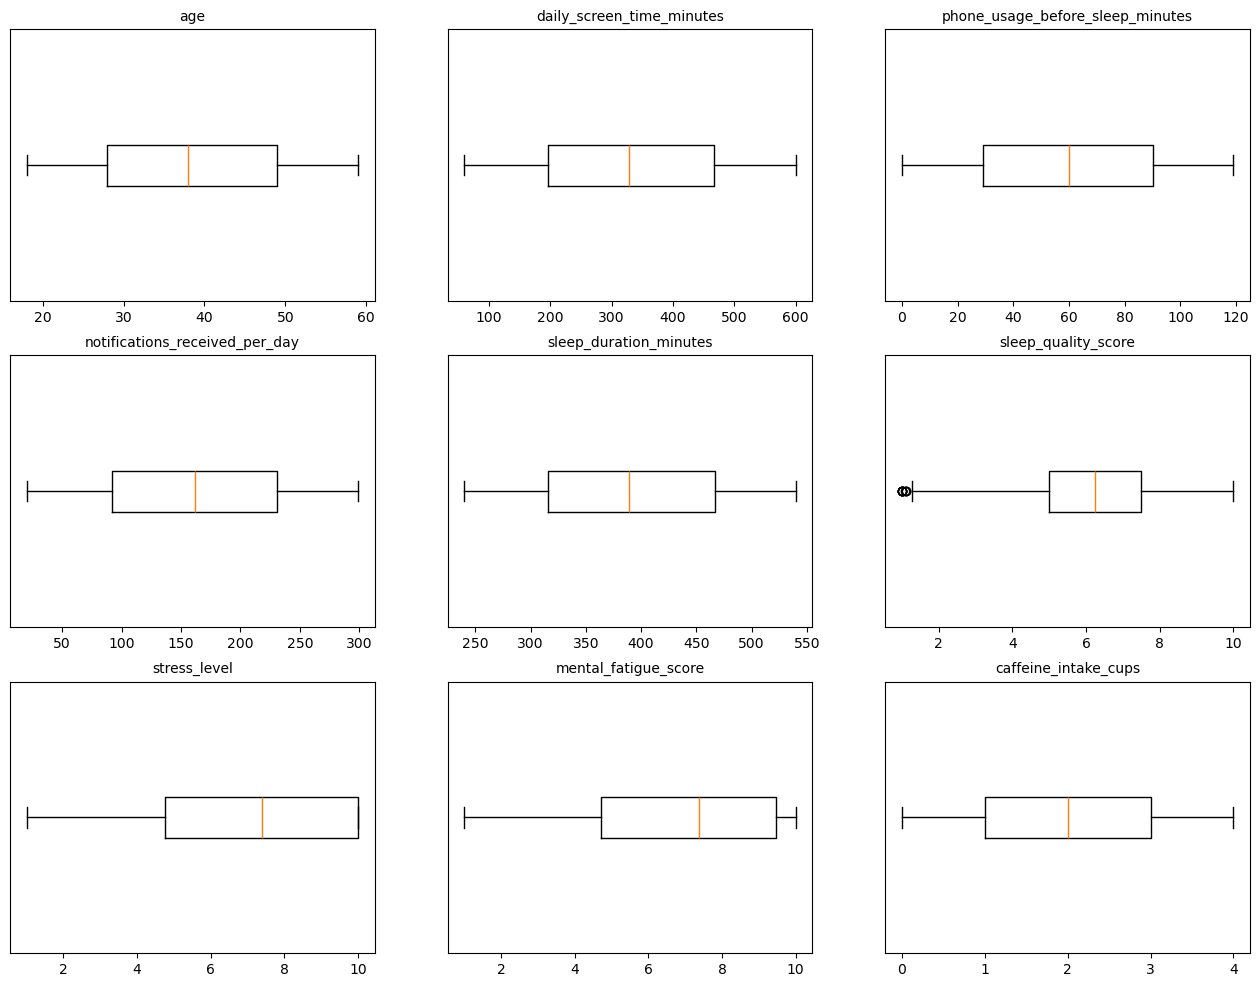

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_yticks([])

# hide any empty subplots if cols < 9
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots for outlier detection', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [18]:
Q1 = df['sleep_quality_score'].quantile(0.25)
Q3 = df['sleep_quality_score'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

sleep_outliers = df[(df['sleep_quality_score'] < lower) | (df['sleep_quality_score'] > upper)]
print(f"Outlier values: {sorted(sleep_outliers['sleep_quality_score'].unique())}")
display(sleep_outliers)

Outlier values: [np.float64(1.0), np.float64(1.09), np.float64(1.11)]


,age,gender,occupation,daily_screen_time_minutes,phone_usage_before_sleep_minutes,notifications_received_per_day,sleep_duration_minutes,sleep_quality_score,stress_level,mental_fatigue_score,caffeine_intake_cups,physical_activity_minutes
253,37,M,manager,578,114,233,278,1.00,10.0,10.00,4,25
519,26,F,student,545,82,80,437,1.00,10.0,10.00,1,59
1434,20,F,designer,598,89,151,386,1.11,10.0,9.31,4,99
2266,45,F,student,556,112,236,264,1.00,10.0,10.00,1,18
5379,29,F,freelancer,578,105,181,269,1.00,10.0,10.00,3,117
7411,18,F,freelancer,541,111,33,502,1.00,10.0,10.00,2,57
9519,23,M,teacher,576,107,111,502,1.11,10.0,8.73,3,100
9592,41,F,researcher,588,98,195,527,1.00,10.0,10.00,0,58
11011,18,M,doctor,583,99,153,499,1.09,10.0,8.69,2,112


In [19]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

skew_df = df[numeric_cols].skew().reset_index()
skew_df.columns = ['column', 'skewness']
skew_df['skewness'] = skew_df['skewness'].round(3)
skew_df['interpretation'] = skew_df['skewness'].apply(
    lambda x: 'fairly normal' if -0.5 <= x <= 0.5 
    else ('moderate skew' if -1 <= x <= 1 
    else 'high skew')
)
print(skew_df)

                             column  skewness interpretation
0                               age     0.008  fairly normal
1         daily_screen_time_minutes     0.008  fairly normal
2  phone_usage_before_sleep_minutes    -0.017  fairly normal
3    notifications_received_per_day    -0.020  fairly normal
4            sleep_duration_minutes     0.003  fairly normal
5               sleep_quality_score    -0.050  fairly normal
6                      stress_level    -0.466  fairly normal
7              mental_fatigue_score    -0.511  moderate skew
8              caffeine_intake_cups     0.001  fairly normal
9         physical_activity_minutes     0.010  fairly normal


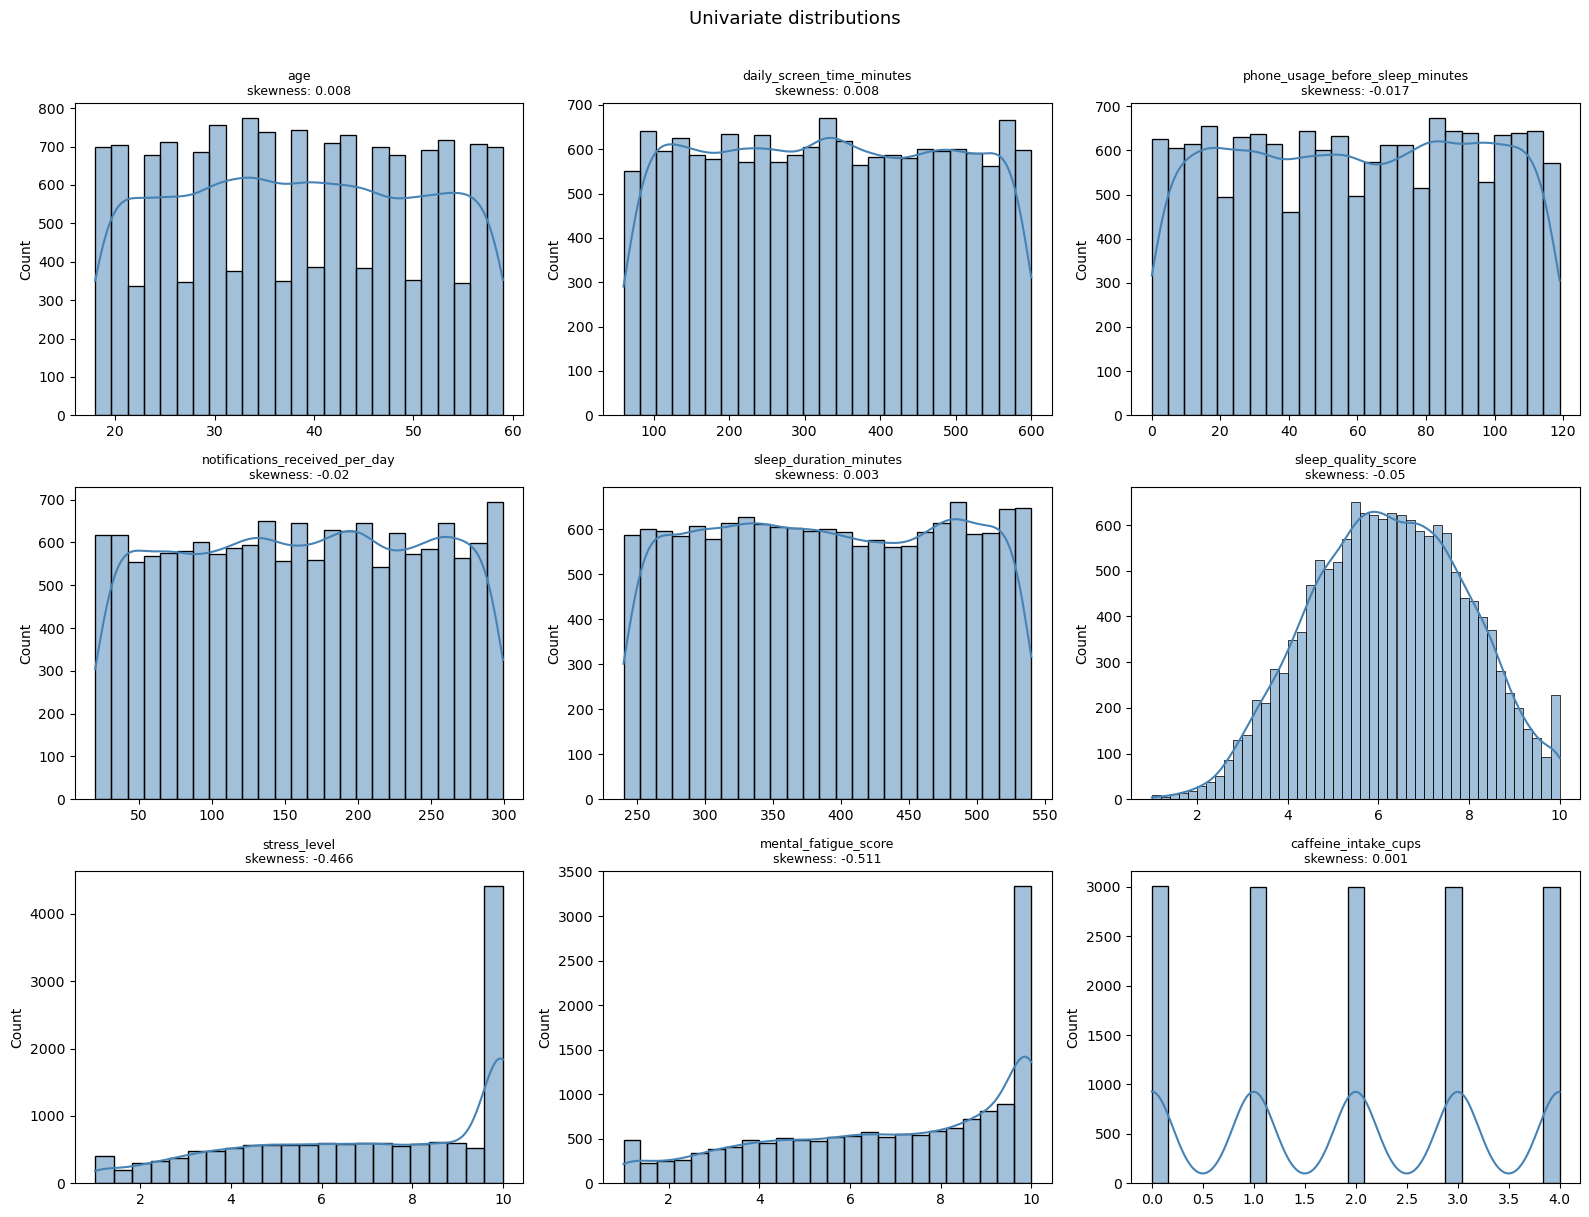

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i >= len(axes):
        break
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col}\nskewness: {round(df[col].skew(), 3)}', fontsize=9)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
df[numeric_cols].describe().round(2)

,age,daily_screen_time_minutes,phone_usage_before_sleep_minutes,notifications_received_per_day,sleep_duration_minutes,sleep_quality_score,stress_level,mental_fatigue_score,caffeine_intake_cups,physical_activity_minutes
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,38.49,330.09,59.71,160.89,390.58,6.25,6.98,6.87,2.00,59.16
std,12.01,156.01,34.64,80.86,87.16,1.71,2.75,2.73,1.41,34.53
min,18.00,60.00,0.00,20.00,240.00,1.00,1.00,1.00,0.00,0.00
25%,28.00,196.00,29.00,92.00,316.00,5.00,4.75,4.70,1.00,29.00
50%,38.00,329.00,60.00,162.00,389.00,6.25,7.38,7.38,2.00,59.00
75%,49.00,466.00,90.00,231.00,467.00,7.50,10.00,9.45,3.00,89.00
max,59.00,600.00,119.00,299.00,540.00,10.00,10.00,10.00,4.00,119.00


In [22]:
# Scaling

In [23]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Original df untouched:")
print(df[numeric_cols].describe().round(2))

Original df untouched:
            age  daily_screen_time_minutes  phone_usage_before_sleep_minutes  \
count  15000.00                   15000.00                          15000.00   
mean      38.49                     330.09                             59.71   
std       12.01                     156.01                             34.64   
min       18.00                      60.00                              0.00   
25%       28.00                     196.00                             29.00   
50%       38.00                     329.00                             60.00   
75%       49.00                     466.00                             90.00   
max       59.00                     600.00                            119.00   

       notifications_received_per_day  sleep_duration_minutes  \
count                        15000.00                15000.00   
mean                           160.89                  390.58   
std                             80.86                   87.16

In [24]:
print("=== Scaled df ===")
print(df_scaled[numeric_cols].describe().round(3))

# every column's min should be 0.0 and max should be 1.0
print("\n=== Min/Max check ===")
print(df_scaled[numeric_cols].min())
print(df_scaled[numeric_cols].max())

=== Scaled df ===
             age  daily_screen_time_minutes  phone_usage_before_sleep_minutes  \
count  15000.000                  15000.000                         15000.000   
mean       0.500                      0.500                             0.502   
std        0.293                      0.289                             0.291   
min        0.000                      0.000                             0.000   
25%        0.244                      0.252                             0.244   
50%        0.488                      0.498                             0.504   
75%        0.756                      0.752                             0.756   
max        1.000                      1.000                             1.000   

       notifications_received_per_day  sleep_duration_minutes  \
count                       15000.000               15000.000   
mean                            0.505                   0.502   
std                             0.290                   0

IndexError: index 9 is out of bounds for axis 0 with size 9

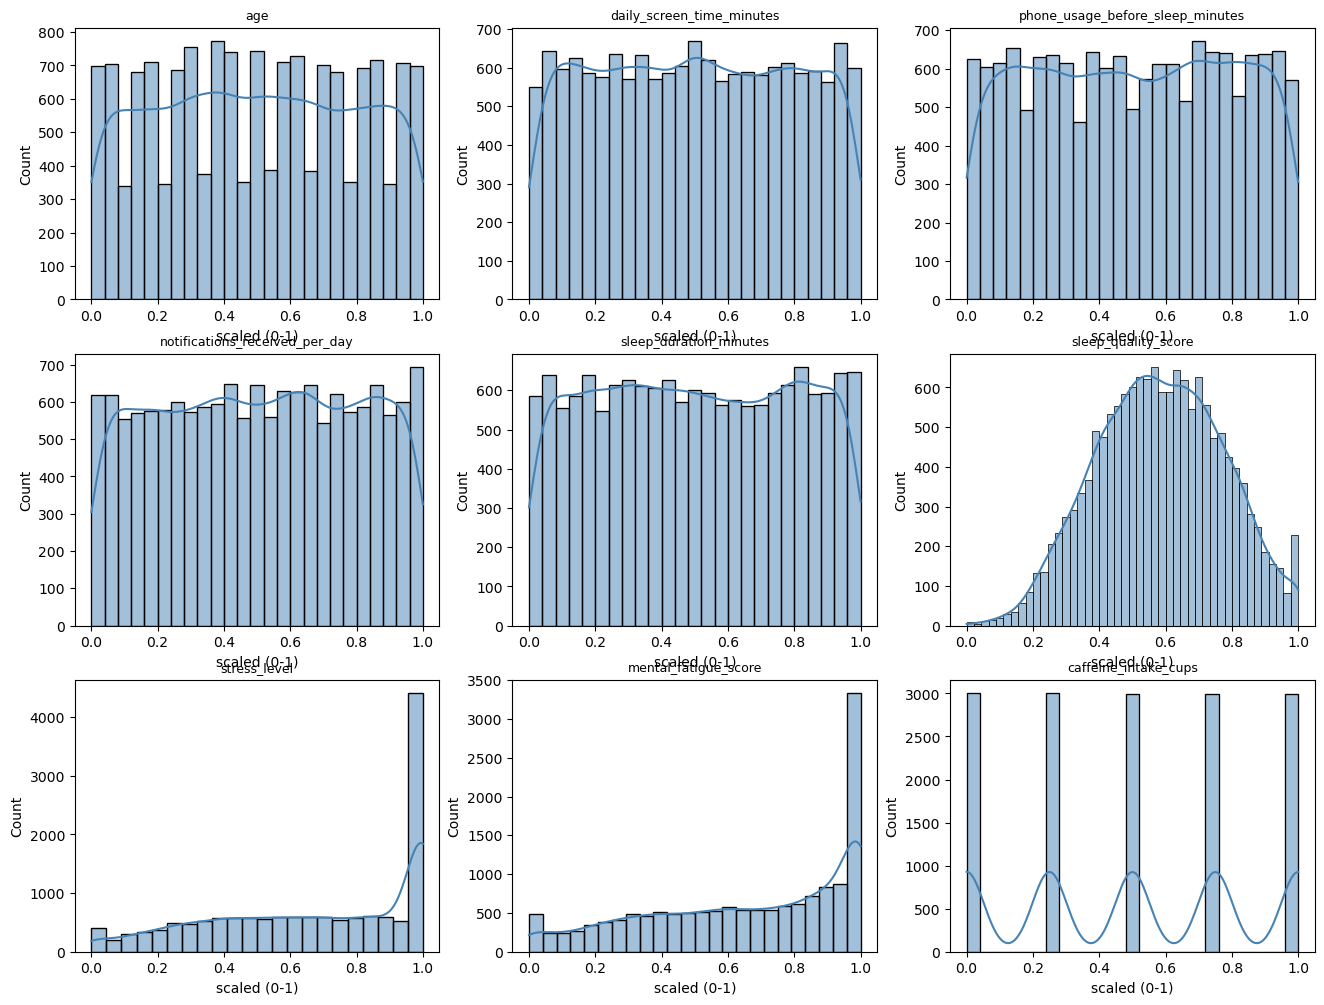

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_scaled[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('scaled (0-1)')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions after Min-Max scaling', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Original df shape     : {df.shape}")
print(f"Scaled df shape       : {df_scaled.shape}")
print(f"\nOriginal df - age min/max : {df['age'].min()}, {df['age'].max()}")
print(f"Scaled df  - age min/max  : {df_scaled['age'].min()}, {df_scaled['age'].max()}")

Original df shape     : (15000, 12)
Scaled df shape       : (15000, 12)

Original df - age min/max : 18, 59
Scaled df  - age min/max  : 0.0, 1.0


In [26]:
df['attention_fragmentation'] = pd.cut(
    df['mental_fatigue_score'],
    bins=[0, 4.0, 7.0, 10.0],
    labels=['low', 'moderate', 'high']
)

# verify distribution
print(df['attention_fragmentation'].value_counts())

attention_fragmentation
high        8041
moderate    4100
low         2859
Name: count, dtype: int64


In [27]:
df.head()

,age,gender,occupation,daily_screen_time_minutes,phone_usage_before_sleep_minutes,notifications_received_per_day,sleep_duration_minutes,sleep_quality_score,stress_level,mental_fatigue_score,caffeine_intake_cups,physical_activity_minutes,attention_fragmentation
0,56,F,designer,196,86,119,319,7.72,3.49,3.57,0,35,low
1,46,F,teacher,111,32,299,442,9.70,3.01,1.91,0,16,low
2,32,F,designer,182,107,21,270,6.38,5.03,6.05,0,17,moderate
3,25,M,software engineer,540,36,220,401,5.53,10.00,9.92,0,3,high
4,38,F,teacher,211,56,167,454,6.69,6.71,5.99,4,92,moderate


In [28]:
print("Gender categories:")
print(df['gender'].unique())
print(f"Count: {df['gender'].nunique()}")

print("\nOccupation categories:")
print(df['occupation'].unique())
print(f"Count: {df['occupation'].nunique()}")

Gender categories:
['F' 'M' nan]
Count: 2

Occupation categories:
['designer' 'teacher' 'software engineer' 'manager' 'student' 'freelancer'
 'doctor' 'researcher']
Count: 8


In [29]:
print(f"Null count in gender: {df['gender'].isnull().sum()}")
print(f"Rows with nan gender:\n")
display(df[df['gender'].isnull()])

Null count in gender: 585
Rows with nan gender:



,age,gender,occupation,daily_screen_time_minutes,phone_usage_before_sleep_minutes,notifications_received_per_day,sleep_duration_minutes,sleep_quality_score,stress_level,mental_fatigue_score,caffeine_intake_cups,physical_activity_minutes,attention_fragmentation
33,24,NaN,software engineer,372,42,148,503,8.36,5.59,7.25,3,2,high
48,52,NaN,researcher,550,100,298,286,3.95,10.00,8.90,4,41,high
52,57,NaN,software engineer,423,44,226,253,4.78,9.74,10.00,2,108,high
57,21,NaN,freelancer,142,29,59,533,8.71,2.43,1.72,4,52,low
85,18,NaN,manager,151,114,31,452,6.58,5.06,3.93,1,2,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14731,22,NaN,software engineer,578,25,37,440,3.55,10.00,9.77,4,14,high
14741,23,NaN,teacher,122,79,287,533,6.63,3.00,1.31,3,56,low
14824,35,NaN,freelancer,97,97,197,530,7.65,3.64,5.45,3,27,moderate
14886,21,NaN,software engineer,348,29,70,448,4.76,7.32,6.62,1,28,moderate


In [30]:
df.drop(df[df['gender'].isnull()].index, inplace=True)
df.reset_index(drop=True, inplace=True)

# verify
print(f"Shape after dropping: {df.shape}")
print(df['gender'].value_counts())
print(f"Nulls remaining: {df['gender'].isnull().sum()}")

Shape after dropping: (14415, 13)
gender
M    7234
F    7181
Name: count, dtype: int64
Nulls remaining: 0


In [31]:
# binary encoding for gender
df['gender'] = df['gender'].map({'M': 0, 'F': 1})

# verify
print(df['gender'].value_counts())
print(df['gender'].unique())

gender
0    7234
1    7181
Name: count, dtype: int64
[1 0]


In [32]:
# one hot for occupation
df = pd.get_dummies(df, columns=['occupation'], prefix='occupation', drop_first=False)

# verify
print(df.shape)
print(df.columns.tolist())

(14415, 20)
['age', 'gender', 'daily_screen_time_minutes', 'phone_usage_before_sleep_minutes', 'notifications_received_per_day', 'sleep_duration_minutes', 'sleep_quality_score', 'stress_level', 'mental_fatigue_score', 'caffeine_intake_cups', 'physical_activity_minutes', 'attention_fragmentation', 'occupation_designer', 'occupation_doctor', 'occupation_freelancer', 'occupation_manager', 'occupation_researcher', 'occupation_software engineer', 'occupation_student', 'occupation_teacher']


In [33]:
# clean column names - replace spaces with underscores
df.columns = df.columns.str.replace(' ', '_')

# verify
print(df.columns.tolist())

['age', 'gender', 'daily_screen_time_minutes', 'phone_usage_before_sleep_minutes', 'notifications_received_per_day', 'sleep_duration_minutes', 'sleep_quality_score', 'stress_level', 'mental_fatigue_score', 'caffeine_intake_cups', 'physical_activity_minutes', 'attention_fragmentation', 'occupation_designer', 'occupation_doctor', 'occupation_freelancer', 'occupation_manager', 'occupation_researcher', 'occupation_software_engineer', 'occupation_student', 'occupation_teacher']


In [34]:
df.head()

,age,gender,daily_screen_time_minutes,phone_usage_before_sleep_minutes,notifications_received_per_day,sleep_duration_minutes,sleep_quality_score,stress_level,mental_fatigue_score,caffeine_intake_cups,physical_activity_minutes,attention_fragmentation,occupation_designer,occupation_doctor,occupation_freelancer,occupation_manager,occupation_researcher,occupation_software_engineer,occupation_student,occupation_teacher
0,56,1,196,86,119,319,7.72,3.49,3.57,0,35,low,True,False,False,False,False,False,False,False
1,46,1,111,32,299,442,9.70,3.01,1.91,0,16,low,False,False,False,False,False,False,False,True
2,32,1,182,107,21,270,6.38,5.03,6.05,0,17,moderate,True,False,False,False,False,False,False,False
3,25,0,540,36,220,401,5.53,10.00,9.92,0,3,high,False,False,False,False,False,True,False,False
4,38,1,211,56,167,454,6.69,6.71,5.99,4,92,moderate,False,False,False,False,False,False,False,True


In [35]:
from sklearn.preprocessing import LabelEncoder

order_map = {'low': 0, 'moderate': 1, 'high': 2}
df['attention_fragmentation'] = df['attention_fragmentation'].map(order_map)

# verify
print(df['attention_fragmentation'].value_counts().sort_index())

attention_fragmentation
0    2746
1    3946
2    7723
Name: count, dtype: int64


In [36]:
df.head()

,age,gender,daily_screen_time_minutes,phone_usage_before_sleep_minutes,notifications_received_per_day,sleep_duration_minutes,sleep_quality_score,stress_level,mental_fatigue_score,caffeine_intake_cups,physical_activity_minutes,attention_fragmentation,occupation_designer,occupation_doctor,occupation_freelancer,occupation_manager,occupation_researcher,occupation_software_engineer,occupation_student,occupation_teacher
0,56,1,196,86,119,319,7.72,3.49,3.57,0,35,0,True,False,False,False,False,False,False,False
1,46,1,111,32,299,442,9.70,3.01,1.91,0,16,0,False,False,False,False,False,False,False,True
2,32,1,182,107,21,270,6.38,5.03,6.05,0,17,1,True,False,False,False,False,False,False,False
3,25,0,540,36,220,401,5.53,10.00,9.92,0,3,2,False,False,False,False,False,True,False,False
4,38,1,211,56,167,454,6.69,6.71,5.99,4,92,1,False,False,False,False,False,False,False,True


In [37]:
# convert all occupation boolean columns to int
occupation_cols = [col for col in df.columns if col.startswith('occupation_')]
df[occupation_cols] = df[occupation_cols].astype(int)

# verify
print(df[occupation_cols].head())
print(df[occupation_cols].dtypes)

   occupation_designer  occupation_doctor  occupation_freelancer  \
0                    1                  0                      0   
1                    0                  0                      0   
2                    1                  0                      0   
3                    0                  0                      0   
4                    0                  0                      0   

   occupation_manager  occupation_researcher  occupation_software_engineer  \
0                   0                      0                             0   
1                   0                      0                             0   
2                   0                      0                             0   
3                   0                      0                             1   
4                   0                      0                             0   

   occupation_student  occupation_teacher  
0                   0                   0  
1                   0             

In [38]:
print(df.dtypes)
print(df.shape)
df.head()

age                                    int64
gender                                 int64
daily_screen_time_minutes              int64
phone_usage_before_sleep_minutes       int64
notifications_received_per_day         int64
sleep_duration_minutes                 int64
sleep_quality_score                  float64
stress_level                         float64
mental_fatigue_score                 float64
caffeine_intake_cups                   int64
physical_activity_minutes              int64
attention_fragmentation             category
occupation_designer                    int64
occupation_doctor                      int64
occupation_freelancer                  int64
occupation_manager                     int64
occupation_researcher                  int64
occupation_software_engineer           int64
occupation_student                     int64
occupation_teacher                     int64
dtype: object
(14415, 20)


,age,gender,daily_screen_time_minutes,phone_usage_before_sleep_minutes,notifications_received_per_day,sleep_duration_minutes,sleep_quality_score,stress_level,mental_fatigue_score,caffeine_intake_cups,physical_activity_minutes,attention_fragmentation,occupation_designer,occupation_doctor,occupation_freelancer,occupation_manager,occupation_researcher,occupation_software_engineer,occupation_student,occupation_teacher
0,56,1,196,86,119,319,7.72,3.49,3.57,0,35,0,1,0,0,0,0,0,0,0
1,46,1,111,32,299,442,9.70,3.01,1.91,0,16,0,0,0,0,0,0,0,0,1
2,32,1,182,107,21,270,6.38,5.03,6.05,0,17,1,1,0,0,0,0,0,0,0
3,25,0,540,36,220,401,5.53,10.00,9.92,0,3,2,0,0,0,0,0,1,0,0
4,38,1,211,56,167,454,6.69,6.71,5.99,4,92,1,0,0,0,0,0,0,0,1


In [39]:
df['attention_fragmentation'] = df['attention_fragmentation'].astype(int)

# verify
print(df['attention_fragmentation'].dtype)
print(df['attention_fragmentation'].value_counts().sort_index())

int64
attention_fragmentation
0    2746
1    3946
2    7723
Name: count, dtype: int64


In [40]:
## Handling Corellations and Multicollinearity

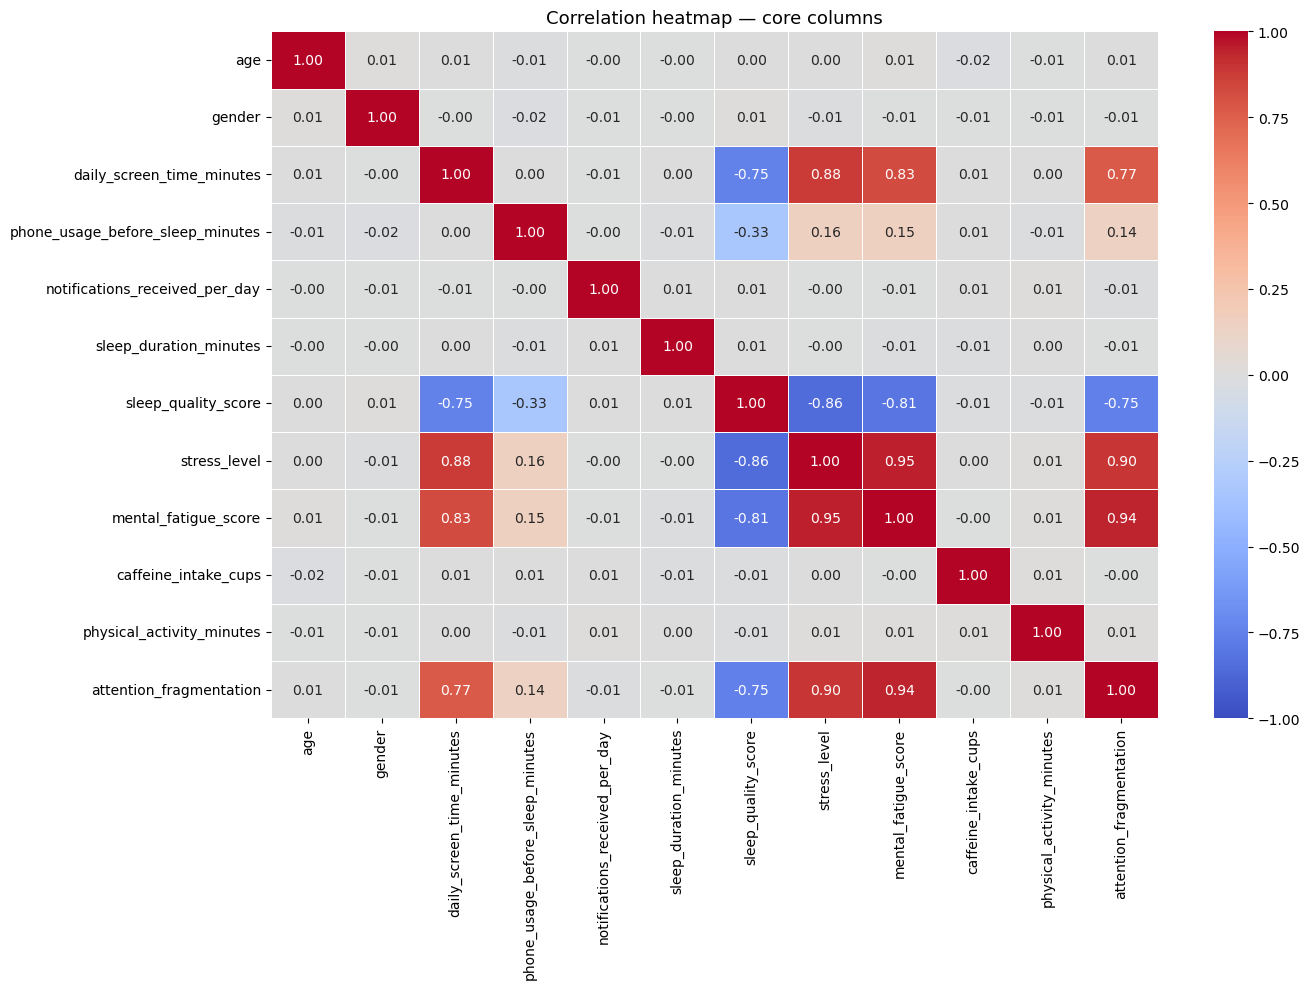

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# exclude occupation one-hot columns for cleaner view first
core_cols = ['age', 'gender', 'daily_screen_time_minutes', 
             'phone_usage_before_sleep_minutes', 'notifications_received_per_day',
             'sleep_duration_minutes', 'sleep_quality_score', 'stress_level', 
             'mental_fatigue_score', 'caffeine_intake_cups', 
             'physical_activity_minutes', 'attention_fragmentation']

corr_matrix = df[core_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Correlation heatmap — core columns', fontsize=13)''
plt.tight_layout()
plt.show()

In [42]:
# find all pairs with correlation > 0.85 (excluding self correlation)
threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > threshold:
            high_corr_pairs.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': round(corr_val, 3)
            })

if high_corr_pairs:
    print(f"High correlation pairs (>{threshold}):")
    print(pd.DataFrame(high_corr_pairs))
else:
    print(f"No pairs found with correlation > {threshold}")

High correlation pairs (>0.85):
                   feature_1                feature_2  correlation
0  daily_screen_time_minutes             stress_level        0.879
1        sleep_quality_score             stress_level       -0.858
2               stress_level     mental_fatigue_score        0.949
3               stress_level  attention_fragmentation        0.898
4       mental_fatigue_score  attention_fragmentation        0.940


In [43]:
# how each feature correlates with our two targets
print("=== Correlation with sleep_quality_score (regression target) ===")
print(df[core_cols].corr()['sleep_quality_score'].sort_values(ascending=False).round(3))

print("\n=== Correlation with attention_fragmentation (classification target) ===")
print(df[core_cols].corr()['attention_fragmentation'].sort_values(ascending=False).round(3))

=== Correlation with sleep_quality_score (regression target) ===
sleep_quality_score                 1.000
gender                              0.013
sleep_duration_minutes              0.007
notifications_received_per_day      0.005
age                                 0.003
physical_activity_minutes          -0.008
caffeine_intake_cups               -0.009
phone_usage_before_sleep_minutes   -0.334
daily_screen_time_minutes          -0.747
attention_fragmentation            -0.752
mental_fatigue_score               -0.808
stress_level                       -0.858
Name: sleep_quality_score, dtype: float64

=== Correlation with attention_fragmentation (classification target) ===
attention_fragmentation             1.000
mental_fatigue_score                0.940
stress_level                        0.898
daily_screen_time_minutes           0.773
phone_usage_before_sleep_minutes    0.139
physical_activity_minutes           0.012
age                                 0.006
caffeine_intake_cups 

In [44]:
# what we got as output:

# Regression — predicting sleep_quality_score
regression_features = [
    'daily_screen_time_minutes',
    'phone_usage_before_sleep_minutes',
    'stress_level',           # keep one of the two highly correlated pair
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'age',
    'gender'
]
# drop mental_fatigue_score (0.949 correlated with stress_level)
# drop notifications, sleep_duration (near zero correlation with target)

# Classification — predicting attention_fragmentation
classification_features = [
    'daily_screen_time_minutes',
    'phone_usage_before_sleep_minutes',
    'sleep_quality_score',
    'sleep_duration_minutes',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'age',
    'gender'
]
# drop mental_fatigue_score (leakage — target was binned from it)
# drop stress_level (0.898 correlated with target — leakage risk)
# drop notifications (near zero correlation)

In [45]:
### Feature Engineering

In [46]:
df['sleep_efficiency_score'] = (df['sleep_quality_score'] / df['sleep_duration_minutes'] * 100).round(4)

print(df['sleep_efficiency_score'].describe().round(4))

count    14415.0000
mean         1.6867
std          0.6202
min          0.1898
25%          1.2351
50%          1.6048
75%          2.0495
max          4.1494
Name: sleep_efficiency_score, dtype: float64


#### Feature Engineering — Sleep Efficiency Score
- Created `sleep_efficiency_score` as sleep quality per unit of sleep duration.
- Captures how efficiently a person sleeps rather than just how long or how well.
- Formula: (sleep_quality_score / sleep_duration_minutes) * 100

In [47]:
df['stress_fatigue_index'] = ((df['stress_level'] + df['mental_fatigue_score']) / 2).round(4)

print(df['stress_fatigue_index'].describe().round(4))

count    14415.0000
mean         6.9239
std          2.7048
min          1.0000
25%          4.7400
50%          7.3800
75%          9.5450
max         10.0000
Name: stress_fatigue_index, dtype: float64


##### Feature Engineering — Stress Fatigue Index
- Created `stress_fatigue_index` by averaging stress_level and mental_fatigue_score.
- These two columns were 0.949 correlated — combining them reduces multicollinearity
- while retaining the information both carried.
- Formula: (stress_level + mental_fatigue_score) / 2

In [48]:
df['digital_wellbeing_score'] = ((df['physical_activity_minutes'] - df['daily_screen_time_minutes']) / (df['stress_level'] + 1)).round(4)

print(df['digital_wellbeing_score'].describe().round(4))

count    14415.0000
mean       -31.5092
std         14.0169
min       -109.5000
25%        -41.7078
50%        -33.5526
75%        -23.3036
max         26.5000
Name: digital_wellbeing_score, dtype: float64


##### Feature Engineering — Digital Wellbeing Score
- Created `digital_wellbeing_score` to capture balance between healthy behavior
- and digital burden relative to stress.
- Positive score = healthy lifestyle outweighing digital burden.
- Negative score = digital overload dominating healthy behavior.
- Formula: (physical_activity_minutes - daily_screen_time_minutes) / (stress_level + 1)

In [49]:
new_features = ['sleep_efficiency_score', 'stress_fatigue_index', 'digital_wellbeing_score']

print("=== New features summary ===")
print(df[new_features].describe().round(4))

print(f"\nDF shape after feature engineering: {df.shape}")
print(f"\nAll columns: {df.columns.tolist()}")

=== New features summary ===
       sleep_efficiency_score  stress_fatigue_index  digital_wellbeing_score
count              14415.0000            14415.0000               14415.0000
mean                   1.6867                6.9239                 -31.5092
std                    0.6202                2.7048                  14.0169
min                    0.1898                1.0000                -109.5000
25%                    1.2351                4.7400                 -41.7078
50%                    1.6048                7.3800                 -33.5526
75%                    2.0495                9.5450                 -23.3036
max                    4.1494               10.0000                  26.5000

DF shape after feature engineering: (14415, 23)

All columns: ['age', 'gender', 'daily_screen_time_minutes', 'phone_usage_before_sleep_minutes', 'notifications_received_per_day', 'sleep_duration_minutes', 'sleep_quality_score', 'stress_level', 'mental_fatigue_score', 'caffeine

##### Feature Engineering — Final Verification
- Confirmed all 3 engineered features created successfully.
- DF shape updated from (14415, 20) to (14415, 23).
- All new features are float64 and contain no null values.

In [50]:
##### Feature Selection

In [51]:
# cols_to_drop = [
#     'stress_level',                    # replaced by stress_fatigue_index
#     'mental_fatigue_score',            # replaced by stress_fatigue_index + leakage risk
#     'notifications_received_per_day',  # near zero correlation with both targets
#     'age',                             # near zero correlation with both targets
#     'gender',                          # near zero correlation with both targets
#     'caffeine_intake_cups',            # captured in digital_wellbeing_score
#     'physical_activity_minutes'        # captured in digital_wellbeing_score
# ]

# regression_features = [
#     'daily_screen_time_minutes',
#     'phone_usage_before_sleep_minutes',
#     'sleep_duration_minutes',
#     'sleep_efficiency_score',
#     'stress_fatigue_index',
#     'digital_wellbeing_score',
#     'occupation_designer',
#     'occupation_doctor',
#     'occupation_freelancer',
#     'occupation_manager',
#     'occupation_researcher',
#     'occupation_software_engineer',
#     'occupation_student',
#     'occupation_teacher'
#     # target → sleep_quality_score
# ]

# classification_features = [
#     'daily_screen_time_minutes',
#     'phone_usage_before_sleep_minutes',
#     'sleep_duration_minutes',
#     'sleep_quality_score',             # feature here, not target
#     'sleep_efficiency_score',
#     'stress_fatigue_index',
#     'digital_wellbeing_score',
#     'occupation_designer',
#     'occupation_doctor',
#     'occupation_freelancer',
#     'occupation_manager',
#     'occupation_researcher',
#     'occupation_software_engineer',
#     'occupation_student',
#     'occupation_teacher'
#     # target → attention_fragmentation
# ]

In [52]:
# in EDA notebook — rebuild df_regression with extra columns
regression_features_v2 = [
    'daily_screen_time_minutes',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_minutes',
    'stress_fatigue_index',
    'digital_wellbeing_score',
    'caffeine_intake_cups',        # bringing back
    'physical_activity_minutes',   # bringing back
    'age',                         # bringing back
    'occupation_designer',
    'occupation_doctor',
    'occupation_freelancer',
    'occupation_manager',
    'occupation_researcher',
    'occupation_software_engineer',
    'occupation_student',
    'occupation_teacher'
]

df_regression_v2 = df[regression_features_v2 + ['sleep_quality_score']].copy()
df_regression_v2.to_csv('df_regression_v2.csv', index=False)
print(f"Saved! Shape: {df_regression_v2.shape}")

Saved! Shape: (14415, 17)


In [53]:
cols_to_drop = [
    'stress_level',                    # replaced by stress_fatigue_index
    'mental_fatigue_score',            # replaced by stress_fatigue_index + leakage risk
    'notifications_received_per_day',  # near zero correlation with both targets
    'age',                             # near zero correlation with both targets
    'gender',                          # near zero correlation with both targets
    'caffeine_intake_cups',            # captured in digital_wellbeing_score
    'physical_activity_minutes'        # captured in digital_wellbeing_score
]

df.drop(columns=cols_to_drop, inplace=True)

print(f"Shape after dropping: {df.shape}")
print(f"\nRemaining columns: {df.columns.tolist()}")

Shape after dropping: (14415, 16)

Remaining columns: ['daily_screen_time_minutes', 'phone_usage_before_sleep_minutes', 'sleep_duration_minutes', 'sleep_quality_score', 'attention_fragmentation', 'occupation_designer', 'occupation_doctor', 'occupation_freelancer', 'occupation_manager', 'occupation_researcher', 'occupation_software_engineer', 'occupation_student', 'occupation_teacher', 'sleep_efficiency_score', 'stress_fatigue_index', 'digital_wellbeing_score']


#### Feature Selection — Dropped Redundant Columns
Dropped 7 columns based on correlation analysis:
- stress_level and mental_fatigue_score replaced by stress_fatigue_index
- notifications_received_per_day, age, gender had near zero correlation with both targets
- caffeine_intake_cups and physical_activity_minutes captured inside digital_wellbeing_score

In [54]:
regression_features = [
    'daily_screen_time_minutes',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_minutes',
    'sleep_efficiency_score',
    'stress_fatigue_index',
    'digital_wellbeing_score',
    'occupation_designer',
    'occupation_doctor',
    'occupation_freelancer',
    'occupation_manager',
    'occupation_researcher',
    'occupation_software_engineer',
    'occupation_student',
    'occupation_teacher'
    # target → sleep_quality_score
]

df_regression = df[regression_features + ['sleep_quality_score']].copy()

print(f"Regression dataset shape: {df_regression.shape}")
print(f"\nColumns: {df_regression.columns.tolist()}")

Regression dataset shape: (14415, 15)

Columns: ['daily_screen_time_minutes', 'phone_usage_before_sleep_minutes', 'sleep_duration_minutes', 'sleep_efficiency_score', 'stress_fatigue_index', 'digital_wellbeing_score', 'occupation_designer', 'occupation_doctor', 'occupation_freelancer', 'occupation_manager', 'occupation_researcher', 'occupation_software_engineer', 'occupation_student', 'occupation_teacher', 'sleep_quality_score']


#### Feature Selection — Regression Dataset
Created df_regression with 14 features + 1 target (sleep_quality_score).
This dataset will be used for regression modeling to predict sleep disruption.

In [55]:
classification_features = [
    'daily_screen_time_minutes',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_minutes',
    'sleep_quality_score',             # feature here, not target
    'sleep_efficiency_score',
    'stress_fatigue_index',
    'digital_wellbeing_score',
    'occupation_designer',
    'occupation_doctor',
    'occupation_freelancer',
    'occupation_manager',
    'occupation_researcher',
    'occupation_software_engineer',
    'occupation_student',
    'occupation_teacher'
    # target → attention_fragmentation
]

df_classification = df[classification_features + ['attention_fragmentation']].copy()

print(f"Classification dataset shape: {df_classification.shape}")
print(f"\nColumns: {df_classification.columns.tolist()}")

Classification dataset shape: (14415, 16)

Columns: ['daily_screen_time_minutes', 'phone_usage_before_sleep_minutes', 'sleep_duration_minutes', 'sleep_quality_score', 'sleep_efficiency_score', 'stress_fatigue_index', 'digital_wellbeing_score', 'occupation_designer', 'occupation_doctor', 'occupation_freelancer', 'occupation_manager', 'occupation_researcher', 'occupation_software_engineer', 'occupation_student', 'occupation_teacher', 'attention_fragmentation']


#### Feature Selection — Classification Dataset
- Created df_classification with 15 features + 1 target (attention_fragmentation).
- sleep_quality_score is used as a feature here, not a target.
- This dataset will be used for classification modeling to predict attention fragmentation levels.

In [56]:
print("=== Master df ===")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

print("\n=== Regression df ===")
print(f"Shape: {df_regression.shape}")
print(f"Features: {regression_features}")
print(f"Target: sleep_quality_score")

print("\n=== Classification df ===")
print(f"Shape: {df_classification.shape}")
print(f"Features: {classification_features}")
print(f"Target: attention_fragmentation")

# confirm no nulls in either
print("\n=== Null check ===")
print(f"df_regression nulls  : {df_regression.isnull().sum().sum()}")
print(f"df_classification nulls: {df_classification.isnull().sum().sum()}")

=== Master df ===
Shape: (14415, 16)
Columns: ['daily_screen_time_minutes', 'phone_usage_before_sleep_minutes', 'sleep_duration_minutes', 'sleep_quality_score', 'attention_fragmentation', 'occupation_designer', 'occupation_doctor', 'occupation_freelancer', 'occupation_manager', 'occupation_researcher', 'occupation_software_engineer', 'occupation_student', 'occupation_teacher', 'sleep_efficiency_score', 'stress_fatigue_index', 'digital_wellbeing_score']

=== Regression df ===
Shape: (14415, 15)
Features: ['daily_screen_time_minutes', 'phone_usage_before_sleep_minutes', 'sleep_duration_minutes', 'sleep_efficiency_score', 'stress_fatigue_index', 'digital_wellbeing_score', 'occupation_designer', 'occupation_doctor', 'occupation_freelancer', 'occupation_manager', 'occupation_researcher', 'occupation_software_engineer', 'occupation_student', 'occupation_teacher']
Target: sleep_quality_score

=== Classification df ===
Shape: (14415, 16)
Features: ['daily_screen_time_minutes', 'phone_usage_bef

#### Feature Selection — Final Verification
Three dataframes confirmed:
- df → master dataframe with all remaining columns
- df_regression → ready for regression modeling (14 features + target)
- df_classification → ready for classification modeling (15 features + target)
No null values in either modeling dataset.

In [57]:
df.to_csv('df_master.csv', index=False)
df_regression.to_csv('df_regression.csv', index=False)
df_classification.to_csv('df_classification.csv', index=False)

print("All three dataframes saved successfully!")

All three dataframes saved successfully!
